In [28]:
import pandas as pd
import numpy as np 
import missingno as msn 
import matplotlib.pyplot as plt 
import seaborn as sns

Carga de datos del csv

In [29]:
df = pd.read_csv("../csv/mushrooms.csv")

df.head(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Información sobre el dataset completo

**Información de Atributos**

<h5 style="color:#1F6AE1;">Clases</h5>

- comestible = e

- venenoso = p

<h5 style="color:#1F6AE1;">Forma del sombrero (cap-shape)</h5>

- campana = b

- cónico = c

- convexo = x

- plano = f

- con protuberancias (nudoso) = k

- hundido = s

<h5 style="color:#1F6AE1;">Superficie del sombrero (cap-surface)</h5>

- fibrosa = f

- con surcos = g

- escamosa = y

- lisa = s

<h5 style="color:#1F6AE1;">Color del sombrero (cap-color)</h5>

- marrón = n

- beige = b

- canela = c

- gris = g

- verde = r

- rosado = p

- púrpura = u

- rojo = e

- blanco = w

- amarillo = y

<h5 style="color:#1F6AE1;">Magulladuras (bruises)</h5>

- con magulladuras = t

- sin magulladuras = f

<h5 style="color:#1F6AE1;">Olor (odor)</h5>

- almendra = a

- anís = l

- creosota = c

- a pescado = y

- fétido = f

- mohoso = m

- ninguno = n

- picante = p

- especiado = s

<h5 style="color:#1F6AE1;">Unión de las láminas (gill-attachment)</h5>

- adheridas = a

- descendentes = d

- libres = f

- escotadas = n

<h5 style="color:#1F6AE1;">Espaciado de las láminas (gill-spacing)</h5>

- juntas = c

- apiñadas = w

- separadas = d

<h5 style="color:#1F6AE1;">Tamaño de las láminas (gill-size)</h5>

- anchas = b

- estrechas = n

<h5 style="color:#1F6AE1;">Color de las láminas (gill-color)</h5>

- negro = k

- marrón = n

- beige = b

- chocolate = h

- gris = g

- verde = r

- naranja = o

- rosado = p

- púrpura = u

- rojo = e

- blanco = w

- amarillo = y

<h5 style="color:#1F6AE1;">Forma del tallo (stalk-shape)</h5>

- ensanchado = e

- afilado = t

<h5 style="color:#1F6AE1;">Raíz del tallo (stalk-root)</h5>

- bulbosa = b

- en forma de maza = c

- con copa = u

- igual = e

- con rizomorfos = z

- enraizada = r

- faltante = ?

<h5 style="color:#1F6AE1;">Superficie del tallo sobre el anillo (stalk-surface-above-ring)</h5>

- fibrosa = f

- escamosa = y

- sedosa = k

- lisa = s

<h5 style="color:#1F6AE1;">Superficie del tallo bajo el anillo (stalk-surface-below-ring)</h5>

- fibrosa = f

- escamosa = y

- sedosa = k

- lisa = s

<h5 style="color:#1F6AE1;">Color del tallo sobre el anillo (stalk-color-above-ring)</h5>

- marrón = n

- beige = b

- canela = c

- gris = g

- naranja = o

- rosado = p

- rojo = e

- blanco = w

- amarillo = y

<h5 style="color:#1F6AE1;">Color del tallo bajo el anillo (stalk-color-below-ring)</h5>

- marrón = n

- beige = b

- canela = c

- gris = g

- naranja = o

- rosado = p

- rojo = e

- blanco = w

- amarillo = y

<h5 style="color:#1F6AE1;">Tipo de velo (veil-type)</h5>

- parcial = p

- universal = u

<h5 style="color:#1F6AE1;">Color del velo (veil-color)</h5>

- marrón = n

- naranja = o

- blanco = w

- amarillo = y

<h5 style="color:#1F6AE1;">Número de anillos (ring-number)</h5>

- ninguno = n

- uno = o

- dos = t

<h5 style="color:#1F6AE1;">Tipo de anillo (ring-type)</h5>

- telarañoso = c

- evanescente = e

- acampanado = f

- grande = l

- ninguno = n

- colgante = p

- envolvente = s

- zonado = z

<h5 style="color:#1F6AE1;">Color de la impresión de esporas (spore-print-color)</h5>

- negro = k

- marrón = n

- beige = b

- chocolate = h

- verde = r

- naranja = o

- púrpura = u

- blanco = w

- amarillo = y

<h5 style="color:#1F6AE1;">Población (population)</h5>

- abundante = a

- agrupada = c

- numerosa = n

- dispersa = s

- varias = v

- solitaria = y

<h5 style="color:#1F6AE1;">Hábitat (habitat)</h5>

- pastos = g

- hojas = l

- praderas = m

- senderos = p

- urbano = u

- desechos = w

- bosque = d

<h5 style="color:#1F6AE1;">creamos una copia del dataset</h5>

In [30]:
df_copy = df.copy()

df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

<h5 style="color:#1F6AE1;">Ver los datos nulos del dataset</h5>

<Axes: >

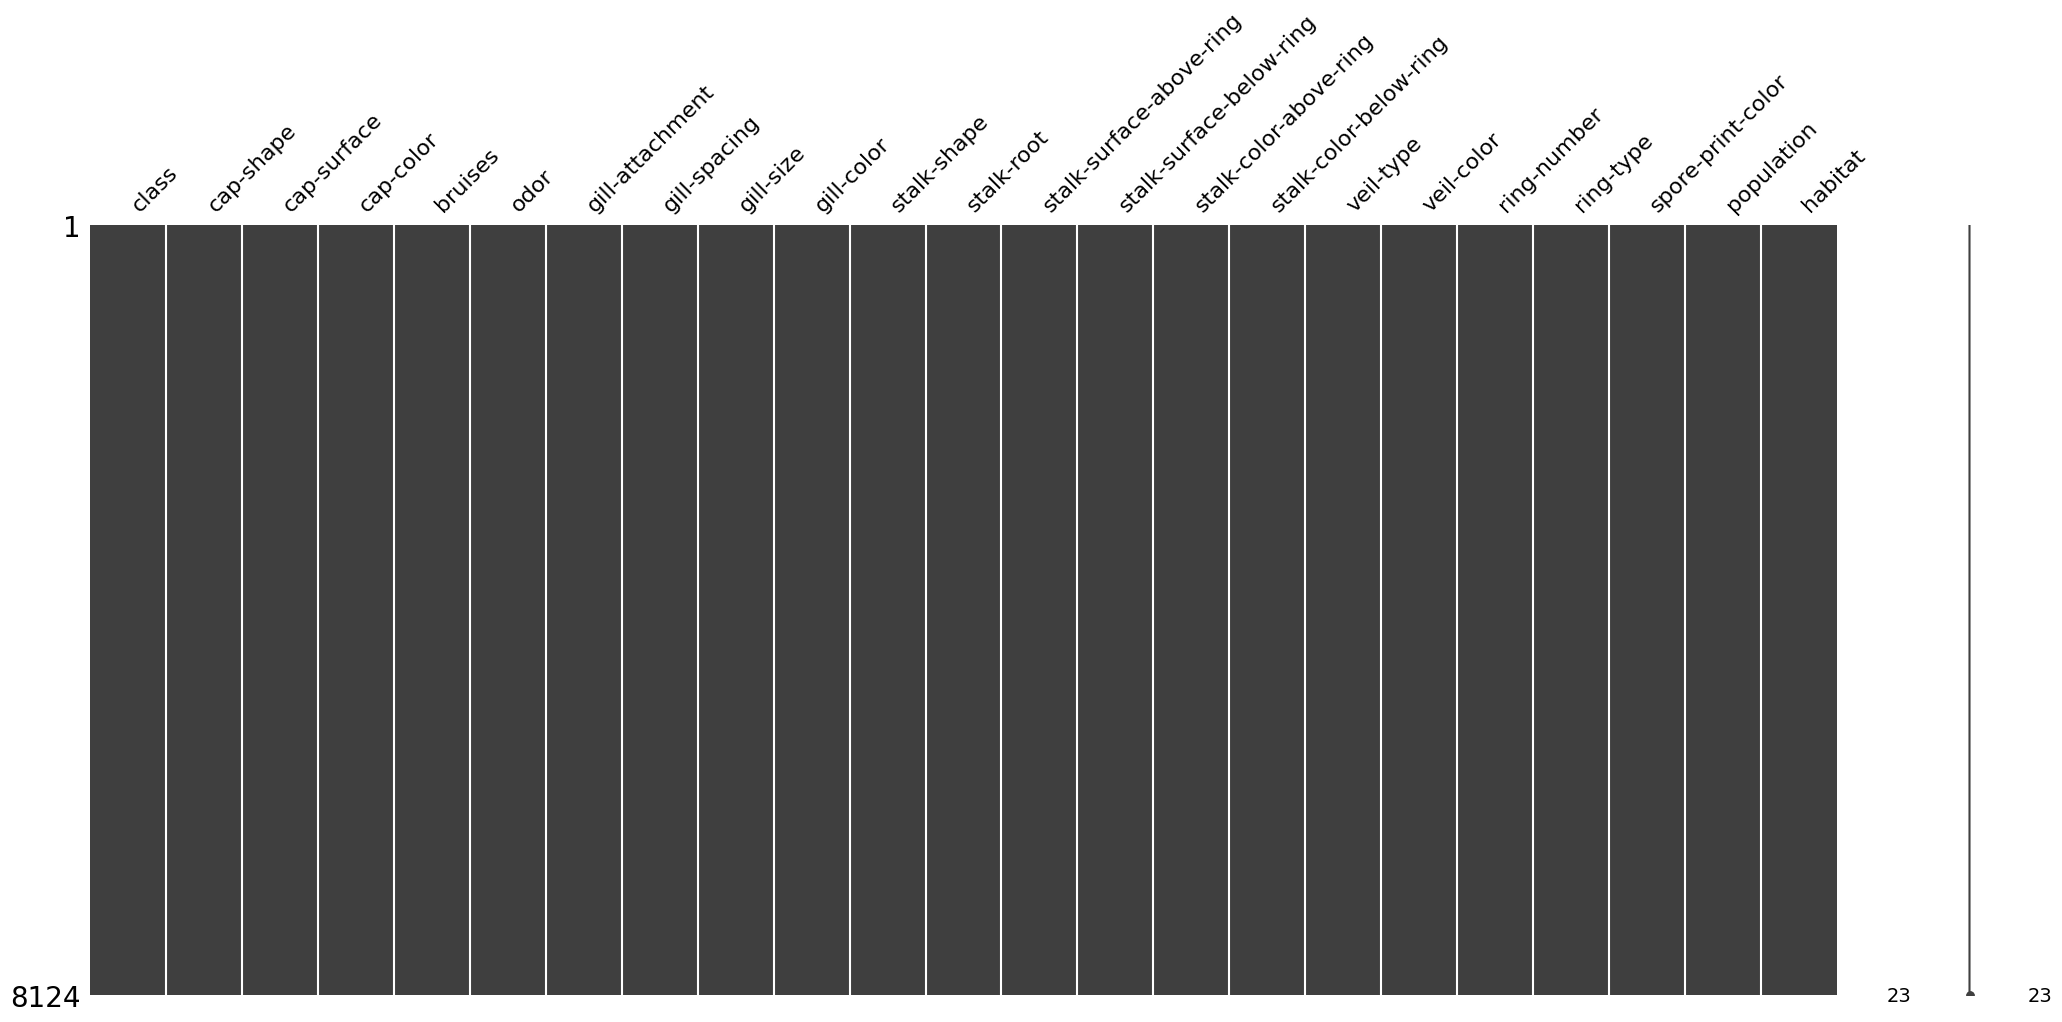

In [31]:
msn.matrix(df)

<h5 style="color:#1F6AE1;">No existen valores nulos dentro del dataset, por lo que no hay que hacer ningun tratamiento en este ámbito</h5>

<h5 style="color:#1F6AE1;">Pasamos los datos de tipo str a categoricos.</h5>

In [32]:
for col in df_copy.columns:
    df_copy[col] = df_copy[col].astype("category")

df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   class                     8124 non-null   category
 1   cap-shape                 8124 non-null   category
 2   cap-surface               8124 non-null   category
 3   cap-color                 8124 non-null   category
 4   bruises                   8124 non-null   category
 5   odor                      8124 non-null   category
 6   gill-attachment           8124 non-null   category
 7   gill-spacing              8124 non-null   category
 8   gill-size                 8124 non-null   category
 9   gill-color                8124 non-null   category
 10  stalk-shape               8124 non-null   category
 11  stalk-root                8124 non-null   category
 12  stalk-surface-above-ring  8124 non-null   category
 13  stalk-surface-below-ring  8124 non-null   category
 14  sta

<h5 style="color:#1F6AE1;">vemos el numero de valores unicos por cada uno de las columnas</h5>

In [33]:
for col in df_copy.columns:
    print(f"Column '{col}' has {df_copy[col].nunique()} unique values")

Column 'class' has 2 unique values
Column 'cap-shape' has 6 unique values
Column 'cap-surface' has 4 unique values
Column 'cap-color' has 10 unique values
Column 'bruises' has 2 unique values
Column 'odor' has 9 unique values
Column 'gill-attachment' has 2 unique values
Column 'gill-spacing' has 2 unique values
Column 'gill-size' has 2 unique values
Column 'gill-color' has 12 unique values
Column 'stalk-shape' has 2 unique values
Column 'stalk-root' has 5 unique values
Column 'stalk-surface-above-ring' has 4 unique values
Column 'stalk-surface-below-ring' has 4 unique values
Column 'stalk-color-above-ring' has 9 unique values
Column 'stalk-color-below-ring' has 9 unique values
Column 'veil-type' has 1 unique values
Column 'veil-color' has 4 unique values
Column 'ring-number' has 3 unique values
Column 'ring-type' has 5 unique values
Column 'spore-print-color' has 9 unique values
Column 'population' has 6 unique values
Column 'habitat' has 7 unique values


<h5 style="color:#1F6AE1;">Se ha realizado un estudio para ver las variables que tienen mayor influencia dentro del dataset en cuanto a que una planta sea venososa o comestible, para ello hemos analizado patrones sobre las distintas variables para ver las distintas columnas y como afecta a ello.</h5>

<h5 style="color:#1F6AE1;">Eliminar las siguientes columnas: veil-type, stalk root.</h5>

<h5 style="color:#1F6AE1;">Estas columnas se deciden eliminar ya que no van a influir en el modelo posteriormente debido a que independientemente de si es venososa o comestible puede aparecer en la seta en sí por lo que no va a ser algo de lo que podamos sacar un patrón.</h5>

<h5 style="color:#1F6AE1;">Dentro de las columnas que mantenemos hay algunas que podemos ver que se corresponden en su totalidad a setas que son de uno de los tipos. Por ejemplo podemos deducir que todas las plantas cuyo campo cap-shape es s es de tipo comestible y para las de tipo c son poisoned</h5>

In [34]:
columnas = ["veil-type", "stalk-root"]

df_copy = df_copy.drop(columns=columnas)

df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   class                     8124 non-null   category
 1   cap-shape                 8124 non-null   category
 2   cap-surface               8124 non-null   category
 3   cap-color                 8124 non-null   category
 4   bruises                   8124 non-null   category
 5   odor                      8124 non-null   category
 6   gill-attachment           8124 non-null   category
 7   gill-spacing              8124 non-null   category
 8   gill-size                 8124 non-null   category
 9   gill-color                8124 non-null   category
 10  stalk-shape               8124 non-null   category
 11  stalk-surface-above-ring  8124 non-null   category
 12  stalk-surface-below-ring  8124 non-null   category
 13  stalk-color-above-ring    8124 non-null   category
 14  sta

In [35]:
for col in df_copy.columns:
    if col == 'cap-shape':
        filtered = df_copy[df_copy[col] == 's']
        print(filtered['class'].value_counts())

class
e    32
p     0
Name: count, dtype: int64


<h5 style="color:#1F6AE1;">Extraemos los archivos para poder tratarlos posteriormente en el EDA y los modelos.</h5>

<h5 style="color:#1F6AE1;">Vamos a extraerlos en dos formatos distintos tanto en csv como en formato parquet, este último es para que las variables se exporten con el tipo correcto (categórico).</h5>

In [36]:
df_copy.to_csv("../clean_data/mushrooms_limpio.csv", index=False)
df_copy.to_parquet("../clean_data/mushrooms_limpio.parquet", engine="pyarrow", index=False)